In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import mlflow
import mlflow.lightgbm
import joblib
import optuna
import os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [14]:
df = pd.read_parquet('../data/processed/features.parquet')
df['Date'] = pd.to_datetime(df['Date'])
print("Shape:", df.shape)

Shape: (405058, 31)


In [15]:
TARGET = 'Sales'
EXCLUDE = ['Store', 'Date', 'Sales']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Features (28): ['DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'CompetitionOpenMonths', 'Month', 'Year', 'WeekOfYear', 'DayOfMonth', 'IsWeekend', 'DaysToMonthEnd', 'Promo2Active', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_mean_14', 'sales_rolling_std_14', 'sales_rolling_mean_28', 'sales_rolling_std_28', 'Promo_DayOfWeek', 'StoreType_Promo']


In [17]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def evaluate(y_true, y_pred):
    return {
        'MAPE': round(mape(y_true, y_pred), 4),
        'RMSE': round(rmse(y_true, y_pred), 4),
        'MAE': round(mae(y_true, y_pred), 4)
    }

In [36]:
df_sorted = df.sort_values(['Store', 'Date'])
baseline_preds = df_sorted['sales_lag_7'].values
baseline_actuals = df_sorted[TARGET].values
baseline_metrics = evaluate(baseline_actuals, baseline_preds)
print("Naive baseline:", baseline_metrics)

Naive baseline: {'MAPE': np.float64(38.3487), 'RMSE': np.float64(2996.4479), 'MAE': np.float64(2320.2335)}


In [19]:
dates = sorted(df['Date'].unique())
total_days = len(dates)
n_splits = 5
fold_size = total_days // (n_splits + 1)
gap_days = 7
forecast_horizon = 42

print(f"Total dates: {total_days}")
print(f"Fold size: {fold_size} days")

Total dates: 914
Fold size: 152 days


In [20]:
fold_results = []

for i in range(n_splits):
    train_end_idx = fold_size * (i + 1)
    test_start_idx = train_end_idx + gap_days
    test_end_idx = test_start_idx + forecast_horizon

    if test_end_idx > total_days:
        break

    train_end = dates[train_end_idx]
    test_start = dates[test_start_idx]
    test_end = dates[min(test_end_idx, total_days - 1)]

    train = df[df['Date'] <= train_end]
    test = df[(df['Date'] >= test_start) & (df['Date'] <= test_end)]

    X_train = train[FEATURE_COLS]
    y_train = train[TARGET]
    X_test = test[FEATURE_COLS]
    y_test = test[TARGET]

    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    metrics = evaluate(y_test.values, preds)
    metrics['fold'] = i + 1
    fold_results.append(metrics)
    print(f"Fold {i+1}: MAPE: {metrics['MAPE']:.2f}%")

results_df = pd.DataFrame(fold_results)
print(f"\nDefault model avg MAPE: {results_df['MAPE'].mean():.4f}%")

Fold 1: MAPE: 12.02%
Fold 2: MAPE: 24.26%
Fold 3: MAPE: 17.16%
Fold 4: MAPE: 9.94%
Fold 5: MAPE: 11.42%

Default model avg MAPE: 14.9622%


In [21]:
tune_train = df[df['Date'] <= dates[fold_size * 3]]
tune_test = df[(df['Date'] >= dates[fold_size * 3 + gap_days]) &
               (df['Date'] <= dates[fold_size * 3 + gap_days + forecast_horizon])]

X_tune_train = tune_train[FEATURE_COLS]
y_tune_train = tune_train[TARGET]
X_tune_test = tune_test[FEATURE_COLS]
y_tune_test = tune_test[TARGET]

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tune_train, y_tune_train)
    preds = model.predict(X_tune_test)
    return mape(y_tune_test.values, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params['random_state'] = 42
best_params['verbose'] = -1

print(f"\nBest MAPE: {study.best_value:.4f}%")
print(f"Best params: {best_params}")

Best trial: 24. Best value: 11.9177: 100%|██████████| 50/50 [04:25<00:00,  5.32s/it]


Best MAPE: 11.9177%
Best params: {'n_estimators': 797, 'learning_rate': 0.03215086138572629, 'num_leaves': 123, 'min_child_samples': 69, 'subsample': 0.7161164061015269, 'colsample_bytree': 0.6010312165039251, 'reg_alpha': 5.063769469055489e-08, 'reg_lambda': 9.653431678238737e-07, 'random_state': 42, 'verbose': -1}


In [23]:
tuned_fold_results = []

for i in range(n_splits):
    train_end_idx = fold_size * (i + 1)
    test_start_idx = train_end_idx + gap_days
    test_end_idx = test_start_idx + forecast_horizon

    if test_end_idx > total_days:
        break

    train_end = dates[train_end_idx]
    test_start = dates[test_start_idx]
    test_end = dates[min(test_end_idx, total_days - 1)]

    train = df[df['Date'] <= train_end]
    test = df[(df['Date'] >= test_start) & (df['Date'] <= test_end)]

    X_train = train[FEATURE_COLS]
    y_train = train[TARGET]
    X_test = test[FEATURE_COLS]
    y_test = test[TARGET]

    model = lgb.LGBMRegressor(**best_params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    metrics = evaluate(y_test.values, preds)
    metrics['fold'] = i + 1
    tuned_fold_results.append(metrics)
    print(f"Fold {i+1}: MAPE: {metrics['MAPE']:.2f}%")

tuned_results_df = pd.DataFrame(tuned_fold_results)
print(f"\nTuned model avg MAPE: {tuned_results_df['MAPE'].mean():.4f}%")
print(f"Default model avg MAPE: {results_df['MAPE'].mean():.4f}%")
print(f"Improvement: {results_df['MAPE'].mean() - tuned_results_df['MAPE'].mean():.4f} pts")

Fold 1: MAPE: 11.83%
Fold 2: MAPE: 22.91%
Fold 3: MAPE: 11.92%
Fold 4: MAPE: 9.57%
Fold 5: MAPE: 11.15%

Tuned model avg MAPE: 13.4739%
Default model avg MAPE: 14.9622%
Improvement: 1.4884 pts


In [24]:
tuned_final = lgb.LGBMRegressor(**best_params)
tuned_final.fit(df[FEATURE_COLS], df[TARGET])

# Save last fold data for analysis
last_train = df[df['Date'] <= dates[fold_size * n_splits]]
last_test = df[df['Date'] >= dates[fold_size * n_splits + gap_days]]
X_last = last_train[FEATURE_COLS]
y_last = last_train[TARGET]

print("Final model trained on full dataset")
print(f"last_test shape: {last_test.shape}")

Final model trained on full dataset
last_test shape: (68792, 31)


In [25]:
train_preds = tuned_final.predict(X_last)
train_metrics = evaluate(y_last.values, train_preds)
avg_test_mape = tuned_results_df['MAPE'].mean()

print(f"Train MAPE: {train_metrics['MAPE']:.2f}%")
print(f"Test MAPE: {avg_test_mape:.2f}%")
print(f"Gap: {avg_test_mape - train_metrics['MAPE']:.2f} pts")

if avg_test_mape - train_metrics['MAPE'] < 5:
    print("✓ No significant overfitting")
elif avg_test_mape - train_metrics['MAPE'] < 15:
    print("⚠ Moderate overfitting")
else:
    print("✗ Significant overfitting")

Train MAPE: 8.11%
Test MAPE: 13.47%
Gap: 5.36 pts
⚠ Moderate overfitting


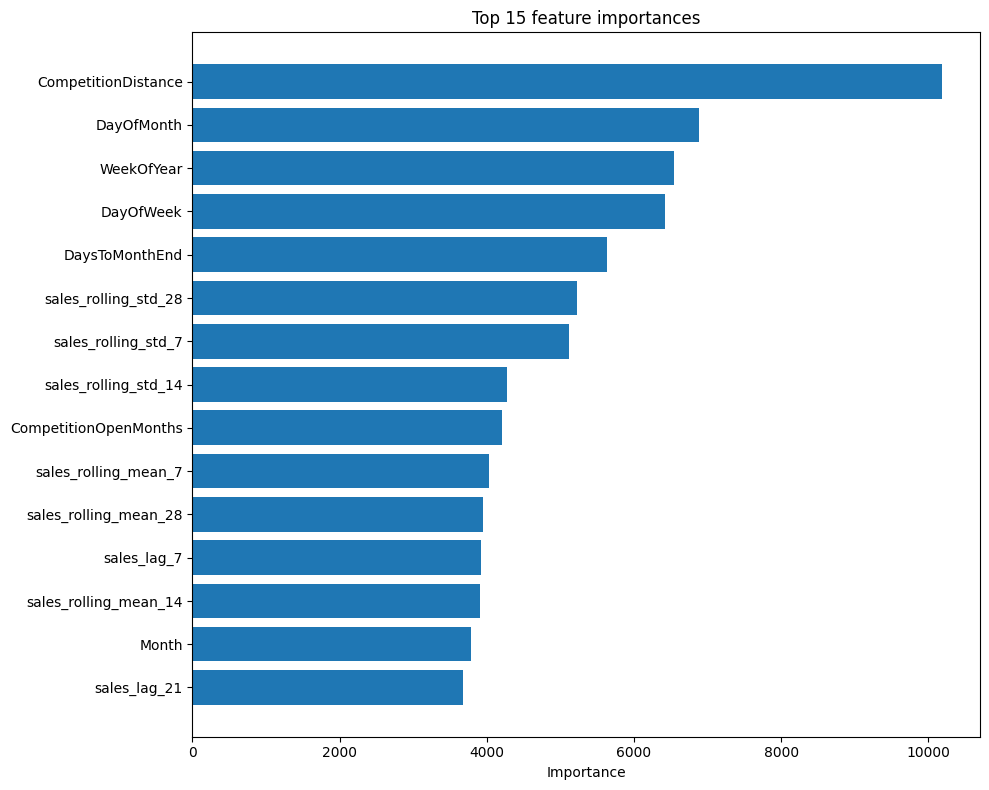

                  feature  importance
6     CompetitionDistance       10194
12             DayOfMonth        6889
11             WeekOfYear        6538
0               DayOfWeek        6417
14         DaysToMonthEnd        5629
25   sales_rolling_std_28        5224
21    sales_rolling_std_7        5121
23   sales_rolling_std_14        4281
8   CompetitionOpenMonths        4208
20   sales_rolling_mean_7        4024


In [26]:
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': tuned_final.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][:15], importance['importance'][:15])
plt.title('Top 15 feature importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.head(10).to_string())

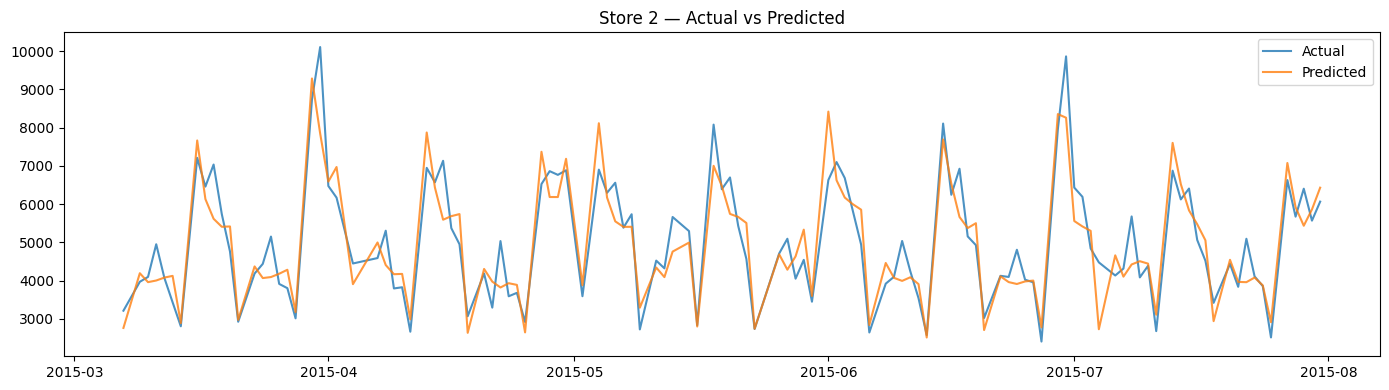

In [27]:
available_stores = last_test['Store'].unique()
store_id = available_stores[0]

store_test = last_test[last_test['Store'] == store_id].copy()
store_test['predicted'] = tuned_final.predict(store_test[FEATURE_COLS])

plt.figure(figsize=(14, 4))
plt.plot(store_test['Date'], store_test['Sales'], label='Actual', alpha=0.8)
plt.plot(store_test['Date'], store_test['predicted'], label='Predicted', alpha=0.8)
plt.title(f'Store {store_id} — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

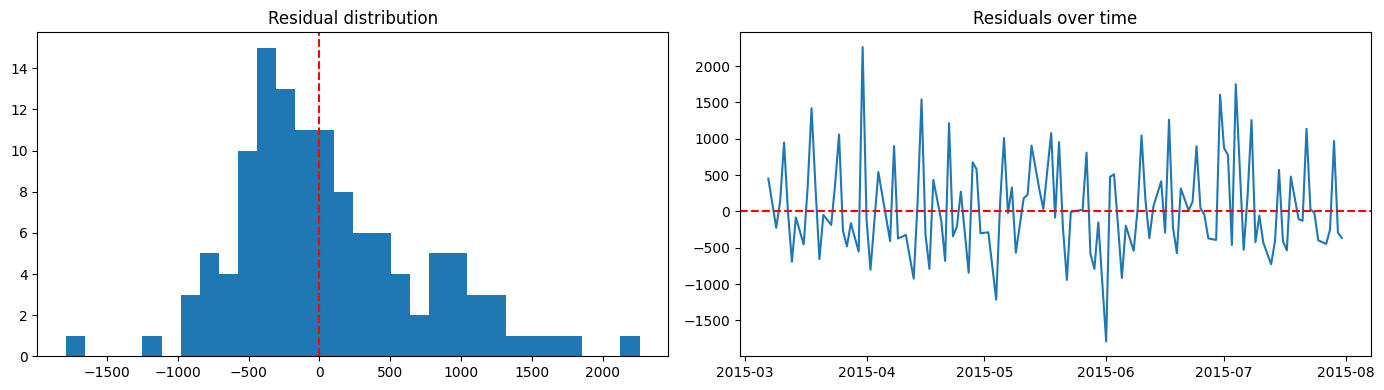

Mean residual: 58.96
Std residual: 668.95


In [31]:
store_test['residual'] = store_test['Sales'] - store_test['predicted']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(store_test['residual'], bins=30)
axes[0].set_title('Residual distribution')
axes[0].axvline(0, color='red', linestyle='--')

axes[1].plot(store_test['Date'], store_test['residual'])
axes[1].set_title('Residuals over time')
axes[1].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print(f"Mean residual: {store_test['residual'].mean():.2f}")
print(f"Std residual: {store_test['residual'].std():.2f}")

In [32]:
store_test_full = last_test[last_test['Store'] == store_id].copy()
store_test_full['predicted'] = tuned_final.predict(store_test_full[FEATURE_COLS])
store_test_full['abs_error'] = (store_test_full['Sales'] - store_test_full['predicted']).abs()

print("Avg error by promo:")
print(store_test_full.groupby('Promo')['abs_error'].mean().round(2))

print("\nAvg error by day of week:")
print(store_test_full.groupby('DayOfWeek')['abs_error'].mean().round(2))

Avg error by promo:
Promo
0    401.60
1    654.97
Name: abs_error, dtype: float64

Avg error by day of week:
DayOfWeek
0    565.03
1    427.42
2    950.93
3    305.51
4    467.19
5    350.21
Name: abs_error, dtype: float64


In [33]:
store_test_full['stockout_risk'] = store_test_full['predicted'] < store_test_full['Sales']
store_test_full['overstock'] = store_test_full['predicted'] > store_test_full['Sales'] * 1.2

print(f"Stockout risk days: {store_test_full['stockout_risk'].sum()} ({store_test_full['stockout_risk'].mean()*100:.1f}%)")
print(f"Overstock risk days: {store_test_full['overstock'].sum()} ({store_test_full['overstock'].mean()*100:.1f}%)")

Stockout risk days: 54 (44.6%)
Overstock risk days: 5 (4.1%)


In [34]:
os.makedirs('../models', exist_ok=True)
joblib.dump(tuned_final, '../models/lgbm_model.pkl')
joblib.dump(FEATURE_COLS, '../models/feature_cols.pkl')
joblib.dump(best_params, '../models/best_params.pkl')
print("Model saved")

Model saved


In [41]:
import os

mlflow_path = r'C:\Users\rushi\supply_chain_decision_system\mlruns'
mlflow.set_tracking_uri(f'file:///{mlflow_path}')
mlflow.set_experiment('supply_chain_forecasting')

with mlflow.start_run(run_name='lgbm_default'):
    mlflow.log_params({'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31})
    mlflow.log_metric('avg_mape', results_df['MAPE'].mean())
    mlflow.log_metric('avg_rmse', results_df['RMSE'].mean())
    mlflow.log_metric('avg_mae', results_df['MAE'].mean())
    print("Default run logged")

with mlflow.start_run(run_name='lgbm_tuned'):
    mlflow.log_params(best_params)
    mlflow.log_metric('avg_mape', tuned_results_df['MAPE'].mean())
    mlflow.log_metric('avg_rmse', tuned_results_df['RMSE'].mean())
    mlflow.log_metric('avg_mae', tuned_results_df['MAE'].mean())
    mlflow.log_metric('baseline_mape', baseline_metrics['MAPE'])
    mlflow.log_metric('improvement', baseline_metrics['MAPE'] - tuned_results_df['MAPE'].mean())
    mlflow.lightgbm.log_model(tuned_final, 'model')
    print("Tuned run logged")

2026/06/04 11:59:21 INFO mlflow.tracking.fluent: Experiment with name 'supply_chain_forecasting' does not exist. Creating a new experiment.
2026/06/04 11:59:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Default run logged


2026/06/04 11:59:21 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned run logged
